In [137]:
import os
from skimage.metrics import structural_similarity
from skimage.metrics import mean_squared_error
import math
import numpy as np
import sirf.Gadgetron as pMR
import matplotlib.pyplot as plt


data_path = '/home/jovyan/work/SIRF-Contribs/src/notebooks/'
os.chdir(data_path)
import utils
from utils import plot_rpe_3d, plot_rpe_3d_simple

# Can use either of these two as ground truth
# ground_truth_with_TV = np.load(os.path.join(data_path, 'ground_truth_with_TV.npy'))
# ground_truth_no_TV = np.load(os.path.join(data_path, 'ground_truth_no_TV.npy'))


Nms = 60
file_pattern = r'{}_TV_{:02d}ms_it_{:03d}.h5'
infinite_iterations = 200 # should be 200
_fname = os.path.join(data_path, 'recons_ignore-acq_4bis', f'MS_{Nms}', file_pattern.format('PDHG', Nms, infinite_iterations) )
ground_truth_with_TV = pMR.ImageData(file=_fname).as_array()


def rmse(input_im, ground_truth, border=20):
    if np.shape(input_im)!=np.shape(ground_truth):
        raise ValueError('imgs have diff shape')
    mse = mean_squared_error(np.abs(input_im[border:-border,border:-border,border:-border]), \
        np.abs(ground_truth[border:-border,border:-border,border:-border]))
    return math.sqrt(mse)

def nrmse(input_im, ground_truth, border=20):
    if np.shape(input_im)!=np.shape(ground_truth):
        raise ValueError('imgs have diff shape')
    mse = mean_squared_error(np.abs(input_im[border:-border,border:-border,border:-border]), \
        np.abs(ground_truth[border:-border,border:-border,border:-border]))
    return math.sqrt(mse) / np.max(np.abs(ground_truth))

def ssim(input_im, ground_truth, border=20):
    if np.shape(input_im)!=np.shape(ground_truth):
        raise ValueError('imgs have diff shape')
    res_ssim = structural_similarity(np.abs(input_im[border:-border,border:-border,border:-border]), \
        np.abs(ground_truth[border:-border,border:-border,border:-border]))
    return res_ssim

# merge itrobj
def merge_itrobj(data_path, algo, Nms):
    recons_dir = 'recons_ignore-acq_4bis'
    itrobj = []
    for el in ['', '_orig']:
        itrobj_fname = os.path.join(data_path, recons_dir, f'MS_{Nms}',f'{algo}_itrobj{el}.npy')
        itrobj.append( np.load(itrobj_fname) )
        if el == '':
            # itr = np.asarray(itrobj[-1][0], dtype=int)
            itr = [int(el) for el in itrobj[-1][0]]
        elif el == '_orig':
            # itr_orig = np.asarray(itrobj[-1][0], dtype=int)
            itr_orig = [int(el) for el in itrobj[-1][0]]
        # print (f'opening {itrobj_fname}', itrobj[-1])

    # # itr = [int(el) for el in itrobj[1][0]]
    # itr = np.asarray(itrobj[1][0], dtype=int)
    # # itr_orig = [int(el) for el in itrobj[0][0]]
    # itr_orig = np.asarray(itrobj[0][0], dtype=int)

    # print (itr)
    # print (itr_orig)
    new_itr = []
    new_obj = []

    for i,itrn in enumerate(itr_orig):
        popme = []
        # print (f"Original itr {itrn}")
        for j,jtrn in enumerate(itr):
            if jtrn not in itr_orig and itrn>jtrn and itrn <=30:
                # print (f"{i} should add {jtrn}")
                new_itr.append( jtrn )
                popme.append(j)
                for idx, el in enumerate(itrobj[0][0]):
                    didx = idx
                    if algo == 'SPDHG':
                        didx *= Nms
                    if didx == jtrn:
                        # print (f"{idx}")
                        new_obj.append(  itrobj[0][1][idx])
        for k in popme[::-1]:
            # print (f"popping {k} {itr.pop(k)}")
            itr.pop(k)
        new_itr.append(  itrobj[1][0][i])
        new_obj.append(  itrobj[1][1][i])
        
    return np.asarray([new_itr, new_obj])

def read_data(data_path, algo, Nms, ground_truth):
    recons_dir = 'recons_ignore-acq_4bis'
    if algo not in ['FISTA', 'PDHG', 'SPDHG']:
        raise ValueError('algo must be one of FISTA, PDHG, SPDHG')
    res = {'rmse': [], 'nrmse': [], 'ssim': []}
    file_pattern = r'{}_TV_{:02d}ms_it_{:03d}.h5'
    itrobj_fname = os.path.join(data_path, recons_dir, f'MS_{Nms}',f'{algo}_itrobj.npy')
    itrobj = np.load(itrobj_fname)
    
    res['iterations'] = itrobj[0].astype(int)
    res['objective'] = itrobj[1]
    itr = itrobj[0][1:].astype(int)

    for it in itr:
        _fname = os.path.join(data_path, recons_dir, f'MS_{Nms}', file_pattern.format(algo, Nms, it) )
        if os.path.exists(_fname):
            res['rmse'].append( rmse( pMR.ImageData(file=_fname).as_array(), ground_truth) )
            # res['nrmse'].append( nrmse( pMR.ImageData(file=_fname).as_array(), ground_truth) )
            # res['ssim'].append( ssim( pMR.ImageData(file=_fname).as_array(), ground_truth) )

    return res

In [138]:
# Merge itrobj and save as new
import shutil
recons_dir = 'recons_ignore-acq_4bis'
# for algo in ['PDHG', 'SPDHG', 'FISTA']:
for algo in ['PDHG', 'FISTA']:
    a = merge_itrobj(data_path, algo, 60)
    itrobj_fname = os.path.join(data_path, recons_dir, f'MS_{Nms}',f'{algo}_itrobj.npy')
    itrobj_fname_new = os.path.join(data_path, recons_dir, f'MS_{Nms}',f'{algo}_itrobj_new.npy')
    if not os.path.exists(itrobj_fname_new):
        shutil.copy(itrobj_fname, itrobj_fname_new)
    np.save(itrobj_fname, a)

#SPDHG
# res_spdhg['iterations']
recons_dir = 'recons_ignore-acq_4bis'
algo = 'SPDHG'
fname = os.path.join(data_path, recons_dir, f'MS_{Nms}',f'{algo}_itrobj_new.npy')
a = np.load(fname)
fname = os.path.join(data_path, recons_dir, f'MS_{Nms}',f'{algo}_itrobj_orig.npy')
b = np.load(fname)
blarge = b[0]>30*Nms
print (a[0]/Nms, b[0][blarge]/Nms)
aa = np.hstack([a[0], b[0][blarge]])
bb = np.hstack([a[1], b[1][blarge]])

fname = os.path.join(data_path, recons_dir, f'MS_{Nms}',f'{algo}_itrobj.npy')
np.save(fname, np.asarray([aa,bb]))

# plt.plot(a[0],a[1], 'o', label='PDHG')
# plt.xscale('linear')
# plt.yscale('linear')
# plt.show()
    
# print (a[0])


[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30.] [ 40.  50.  60.  70.  80.  90. 100.]


In [139]:
all_res_pdhg = read_data(data_path, 'PDHG', Nms, ground_truth_with_TV)
res_spdhg = read_data(data_path, 'SPDHG', Nms, ground_truth_with_TV)
res_fista = read_data(data_path, 'FISTA', Nms, ground_truth_with_TV)

0
number of images: 1
image data type: 7
variable xml
group 2024-05-08 22:34:28
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-08 22:50:31
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-08 23:06:21
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-08 23:22:03
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-08 23:37:50
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-08 23:53:29
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-09 00:12:59
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-09 00:29:29
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-09 00:45:27
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-09 04:11:41
variable image_0
number of images: 1
image data type: 7
variable 

In [140]:
# remove the iterations larger than 100 from PDHG
resmaxiter = 100
filt = all_res_pdhg['iterations'] <= resmaxiter
print (filt)
res_pdhg = {}
for k,v in all_res_pdhg.items():
    print (k,v)
    offset = 1
    if k in ['iterations', 'objective']:
        offset = 0
    if len(v) > 0:
        res_pdhg[k] = np.asarray(v)[filt[offset:]]
print (res_pdhg['rmse'])
print(len(res_pdhg['rmse']))

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True False False False False False False False False False False]
rmse [8.05464679886935e-06, 6.643379106631722e-06, 5.257665860438142e-06, 4.087310814229035e-06, 3.0933589497392628e-06, 2.4214121240381014e-06, 2.189899545408977e-06, 2.3503748751335123e-06, 2.6017917732630862e-06, 2.743026693636014e-06, 2.722296608871127e-06, 2.570173576959094e-06, 2.3464518047894537e-06, 2.1100220254747385e-06, 1.914712273610928e-06, 1.7855864229939116e-06, 1.7125137611469348e-06, 1.6639431790172351e-06, 1.6098909170927082e-06, 1.5360486409283634e-06, 1.4455594016110502e-06, 1.351958587586942e-06, 1.2714767603807335e-06, 1.21259319323004e-06, 1.1721357660131806e-06, 1.1405294146220645e-06, 1.1075462143855166e-06, 1.065480792284063e-06, 1.0116266143795675e-06, 9.491424755227395e-

In [141]:
res_spdhg

{'rmse': [1.5116885252440385e-06,
  9.300859908231648e-07,
  7.274440546674788e-07,
  6.390407295442253e-07,
  4.914724478923628e-07,
  4.289210844373459e-07,
  3.6890878189403545e-07,
  3.2678699710402564e-07,
  2.7283189801136585e-07,
  2.2513484100821883e-07,
  1.8533986387429536e-07,
  1.6180024938904407e-07,
  1.3571788048971775e-07,
  1.2858868767261835e-07,
  1.0217959031022432e-07,
  8.58978147901566e-08,
  8.057069012049083e-08,
  6.064948046469625e-08,
  5.795867983684105e-08,
  5.4563182851772105e-08,
  4.663042959579231e-08,
  3.883148440688999e-08,
  3.7444198985152546e-08,
  3.353323782900235e-08,
  2.9170291604145733e-08,
  2.7728095371508243e-08,
  2.132403921661337e-08,
  2.3181602659098807e-08,
  1.7837111182743343e-08,
  1.4592679135244342e-08,
  7.197117905489817e-09,
  6.5264373930701915e-09,
  7.032350604769846e-09,
  7.200055678081892e-09,
  7.330782089762024e-09,
  7.436176871351414e-09,
  7.52544384294608e-09],
 'nrmse': [],
 'ssim': [],
 'iterations': array([ 

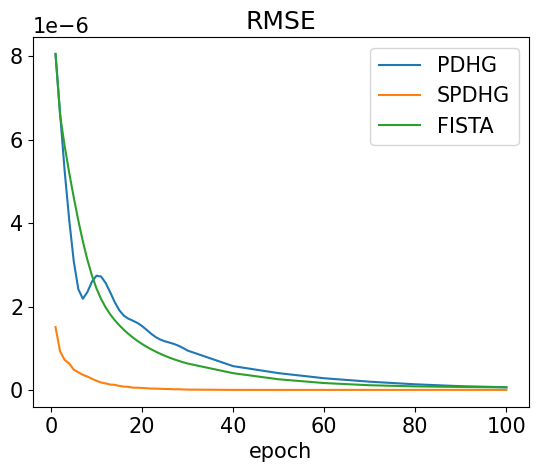

In [142]:
# epochs = [it * 10 for it in range(1,11)]
plt.plot(res_pdhg['iterations'][1:], res_pdhg['rmse'], label='PDHG' )
plt.plot([el / Nms for el in res_spdhg['iterations'][1:]], res_spdhg['rmse'], label='SPDHG' )
plt.plot(res_fista['iterations'][1:], res_fista['rmse'], label='FISTA' )
# plt.plot(epochs_spdhg, res_spdhg_all['rmse'], label='SPDHG' )
plt.legend()
plt.title('RMSE')
plt.xlabel('epoch')
plt.show()

In [143]:
# Determine iteration where the difference is below convergence_threshold
def find_epoch_below_threshold(results, reference_rmse, threshold):
    rmse = results['rmse'] / reference_rmse
    iterations = results['iterations'][1:]
    for i,r in enumerate(rmse):
        if r < threshold:
            return iterations[i]
    return -1

# This is done on RMSE scaled by the np.sqrt(np.mean(reference_recon**2))

reference_rmse = np.sqrt(np.mean(ground_truth_with_TV**2))
convergence_threshold = 0.05

t_pdhg = find_epoch_below_threshold(res_pdhg, reference_rmse, convergence_threshold)
t_spdhg = find_epoch_below_threshold(res_spdhg, reference_rmse, convergence_threshold) / Nms
t_fista = find_epoch_below_threshold(res_fista, reference_rmse, convergence_threshold)
print(f"epoch to threshold: FISTA {t_fista}, PDHG {t_pdhg}, SPDHG {t_spdhg}")

epoch to threshold: FISTA 60, PDHG 70, SPDHG 10.0


In [144]:
t_fista = find_epoch_below_threshold(res_fista, reference_rmse, convergence_threshold)
print(f"epoch to threshold: FISTA {t_fista}, PDHG {t_pdhg}, SPDHG {t_spdhg}")

epoch to threshold: FISTA 60, PDHG 70, SPDHG 10.0


/opt/conda/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


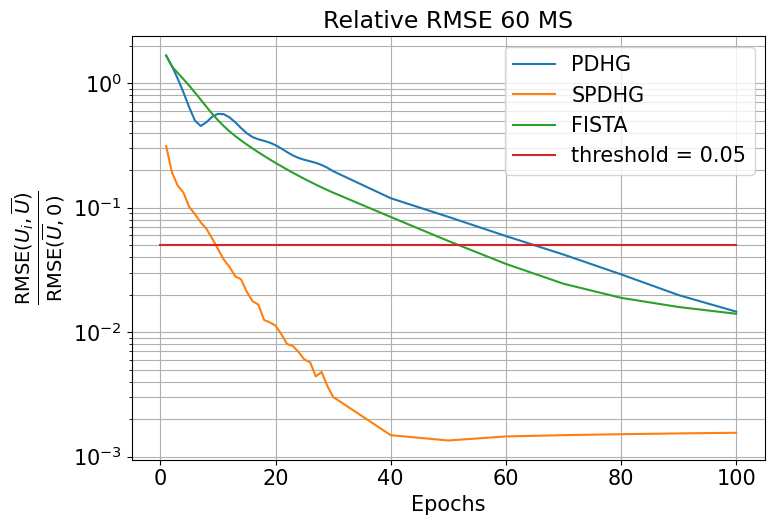

In [179]:
# 

import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
matplotlib.rcParams.update({'font.size': 15})
matplotlib.rcParams['axes.labelsize'] = 15

fig, ax = plt.subplots(nrows=1, ncols=1, squeeze=True, figsize=[8, 5.5])
# plt.rcParams['text.usetex'] = True

plt.plot(res_pdhg['iterations'][1:], res_pdhg['rmse']/reference_rmse, label='PDHG' )#'-o', 
plt.plot([el / Nms for el in res_spdhg['iterations'][1:]], res_spdhg['rmse']/reference_rmse, label='SPDHG' )# '-o',
plt.plot(res_fista['iterations'][1:], res_fista['rmse']/reference_rmse, label='FISTA' )#'-o',
# plt.plot(epochs_spdhg, res_spdhg_all['rmse'], label='SPDHG' )
plt.plot([0,100], [convergence_threshold]*2, '-', label=f'threshold = {convergence_threshold}')
# plt.plot([t_pdhg, t_pdhg], [1e-3, convergence_threshold], '-', color='C0')
# plt.plot([t_spdhg, t_spdhg], [1e-3, convergence_threshold], '-', color='C1')
plt.legend()
plt.title(f'Relative RMSE {Nms} MS', fontsize=17)
plt.xlabel('Epochs')
plt.yscale('log')
plt.ylabel(r'$\frac{\mathrm{RMSE}(U_i, \overline{U})}{\mathrm{RMSE}(\overline{U},0)}$', fontsize=20)
plt.grid(axis='both', which='both')
plt.tight_layout()
plt.savefig('relative_rmse.png', bbox_inches="tight")
plt.show()

In [146]:
def compute_delta_rmse(data_path, algo, Nms):
    recons_dir = 'recons_ignore-acq_4bis'
    if algo not in ['FISTA', 'PDHG', 'SPDHG']:
        raise ValueError('algo must be one of FISTA, PDHG, SPDHG')
    res = {'iterations': [], 'rmse': []}
    file_pattern = r'{}_TV_{:02d}ms_it_{:03d}.h5'
    itrobj_fname = os.path.join(data_path, recons_dir, f'MS_{Nms}',f'{algo}_itrobj.npy')
    itrobj = np.load(itrobj_fname)

    # relevant iterations are from iteration 1
    res['objective'] = itrobj[1]
    itr = itrobj[0][1:].astype(int)
    

    for i in range(2,len(itr)):
        it = itr[i]
        it_prev = itr[i-1]
        _fname = os.path.join(data_path, recons_dir, f'MS_{Nms}', file_pattern.format(algo, Nms, it) )
        _fname_prev = os.path.join(data_path, recons_dir, f'MS_{Nms}', file_pattern.format(algo, Nms, it_prev) )
        #TODO normalise by RMSE of previous iterate
        if os.path.exists(_fname):
            prev_solution = pMR.ImageData(file=_fname_prev).as_array()
            prev_solution_rmse = np.sqrt(np.mean(ground_truth_with_TV**2))
            res['rmse'].append( 
                rmse( pMR.ImageData(file=_fname).as_array(), 
                      prev_solution) / prev_solution_rmse / (it-it_prev)
            )
            res['iterations'].append(it)
            
    return res

drmse_pdhg = compute_delta_rmse(data_path, 'PDHG', Nms)
drmse_spdhg = compute_delta_rmse(data_path, 'SPDHG', Nms)
drmse_fista = compute_delta_rmse(data_path, 'FISTA', Nms)

type: 7
variable xml
group 2024-05-09 00:29:29
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-09 00:45:27
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-09 04:11:41
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-09 07:41:29
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-05 19:35:27
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-05 21:23:41
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-05 23:12:00
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-06 01:00:29
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-06 02:48:58
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-07 13:47:10
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-07 14:08:35
var

In [147]:
print (drmse_spdhg)

{'iterations': [180, 240, 300, 360, 420, 480, 540, 600, 660, 720, 780, 840, 900, 960, 1020, 1080, 1140, 1200, 1260, 1320, 1380, 1440, 1500, 1560, 1620, 1680, 1740, 1800, 2400, 3000, 3600, 4200, 4800, 5400, 6000], 'rmse': [(0.0025899859084741726-0.00023505726892042057j), (0.0021032480418660647-0.00019088279166526965j), (0.0018196384677554589-0.00016514346555079033j), (0.0013483050744556159-0.00012236703969551414j), (0.0012254945512191855-0.00011122122376956968j), (0.0008994198607387442-8.162792522781885e-05j), (0.0008986666119016705-8.155956322867409e-05j), (0.0007645827718565913-6.939062395211774e-05j), (0.0006798956738998549-6.170474508560533e-05j), (0.00048746135276470635-4.4240138106631013e-05j), (0.0004915183469550598-4.4608335466813674e-05j), (0.00041325912650194544-3.750582631131507e-05j), (0.00037841566570818286-3.434356635186122e-05j), (0.0003459877839668877-3.14005351585086e-05j), (0.000288516500521717-2.6184660089932755e-05j), (0.0002664770501946233-2.4184443414836676e-05j), 

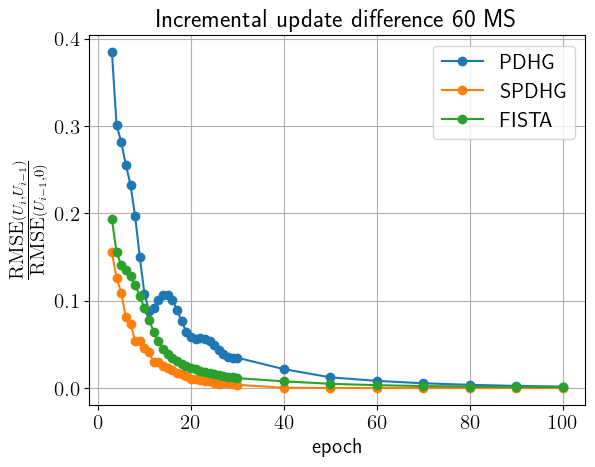

In [148]:
# import matplotlib.pylab as pylab
# params = {'axes.titlesize':'30', 'axes.labelsize':'15'}
# pylab.rcParams.update(params)
plt.rcParams['text.usetex'] = True
plt.rcParams['axes.labelsize'] = 15

# TODO add grid lines on the plot
# green threshold dotted

# incr_threshold = 6.5e-2
incr_threshold = convergence_threshold
min_line = 1e-4

drmse_pdhg['iterations'] = np.asarray(drmse_pdhg['iterations'])
first_100 = drmse_pdhg['iterations']<101
first_30 = drmse_pdhg['iterations']<=30
first_30x = np.asarray(drmse_spdhg['iterations'])<=30*Nms
first_30a = np.asarray(drmse_fista['iterations'])<=30

drmse_pdhg['rmse'] = np.asarray(drmse_pdhg['rmse'])

plt.plot(drmse_pdhg['iterations'][first_100], drmse_pdhg['rmse'][first_100], '-o', label='PDHG' )
# this requires to multiply by the Nms because it is now normalised by the number of epochs between consecutive steps
plt.plot(np.asarray([el / Nms for el in drmse_spdhg['iterations']]), np.asarray(drmse_spdhg['rmse'])*Nms, '-o', label='SPDHG' )
plt.plot(np.asarray(drmse_fista['iterations']), np.asarray(drmse_fista['rmse']), '-o', label='FISTA' )
# plt.plot(res_fista['iterations'][1:], res_fista['rmse'], label='FISTA' )
# plt.plot([0,100], [incr_threshold]*2, '-', label=f'incr convergence threshold = {incr_threshold}')
# plt.plot([0,100], [0.02]*2, '-', label=f'incr convergence threshold = {0.02}')
# plt.plot([t_pdhg, t_pdhg], [min_line, incr_threshold], '-', color='C0')
# plt.plot([t_spdhg, t_spdhg], [min_line, incr_threshold], '-', color='C1')
plt.legend()
plt.title(f'Incremental update difference {Nms} MS')
plt.xlabel('epoch')
plt.yscale('linear')
plt.ylabel(r'$\frac{\textrm{RMSE}(U_i, U_{i-1})}{\textrm{RMSE}(U_{i-1},0)}$')
plt.grid(visible=True, axis='both', which='both')
plt.savefig('incremental_difference.png')
plt.show()

In [149]:
plt.plot(res_pdhg['iterations'][1:], res_pdhg['nrmse'], label='PDHG' )
plt.plot([el / Nms for el in res_spdhg['iterations'][1:]], res_spdhg['nrmse'], label='SPDHG' )
plt.plot(res_fista['iterations'][1:], res_fista['nrmse'], label='FISTA' )
plt.legend()
plt.title('NRMSE')
plt.xlabel('epoch')
plt.show()

KeyError: 'nrmse'

In [15]:
plt.plot(res_pdhg['iterations'][1:], res_pdhg['ssim'], label='PDHG' )
plt.plot([el / Nms for el in res_spdhg['iterations'][1:]], res_spdhg['ssim'], label='SPDHG' )
plt.plot(res_fista['iterations'][1:], res_fista['ssim'], label='FISTA' )
plt.legend()
plt.title('SSIM')
plt.xlabel('epoch')
plt.show()

KeyError: 'ssim'

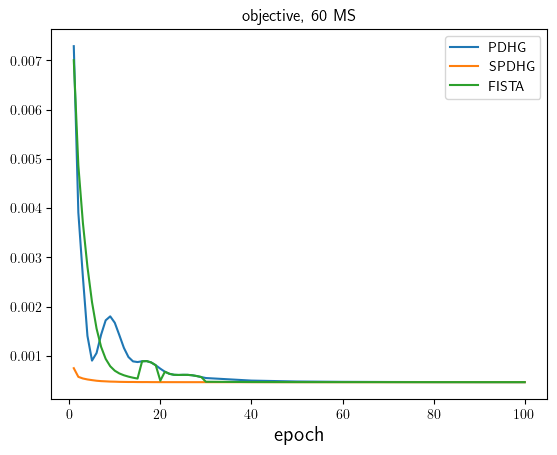

In [16]:

offset = 1
scale = 'linear'
plt.plot(res_pdhg['iterations'][offset:], res_pdhg['objective'][offset:], label='PDHG' )
plt.plot([el / Nms for el in res_spdhg['iterations'][offset:]], res_spdhg['objective'][offset:], label='SPDHG' )
plt.plot(res_fista['iterations'][offset:], res_fista['objective'][offset:], label='FISTA' )
plt.xscale(scale)
plt.title(f'objective, {Nms} MS')
plt.xlabel('epoch')
plt.legend()
plt.show()



In [ ]:
num_epochs = 20
_fname = os.path.join(data_path, 'recons', f'MS_{Nms}','SPDHG_TV_{}ms_it_{:03d}.h5'.format(Nms, Nms * num_epochs) )
im = pMR.ImageData(_fname)
plot_rpe_3d([im.as_array(), im.as_array() - ground_truth_with_TV],
            [59, 64] * 2,
            [f'SPDHG, {Nms}ms, {num_epochs} epochs', 'difference with GT'],
            [3*10**(-5)]*2,
            f'SPDHG, {Nms}ms.png')

In [ ]:
_fname = os.path.join(data_path, 'recons', f'MS_{Nms}','PDHG_TV_{}ms_it_{:03d}.h5'.format(Nms, num_epochs) )
im = pMR.ImageData(_fname)
plot_rpe_3d([im.as_array(), im.as_array() -ground_truth_with_TV],
            [59, 64]*2,
            [f'PDHG, {Nms}ms, {num_epochs} epochs', 'difference with GT'],
            [3*10**(-5)]*2,
            f'PDHG, {Nms}ms.png')

In [ ]:
_fname = os.path.join(data_path, 'recons', f'MS_{Nms}','FISTA_TV_{}ms_it_{:03d}.h5'.format(Nms, num_epochs) )
im = pMR.ImageData(_fname)
plot_rpe_3d([im.as_array(), im.as_array() - ground_truth_with_TV],
            [59, 64] * 2,
            [f'FISTA, {Nms}ms, {num_epochs} epochs', 'difference with GT'],
            [3*10**(-5)]*2,
            f'FISTA, {Nms}ms.png')

In [ ]:
plot_rpe_3d([ground_truth_with_TV],
            [59, 64],
            [f'Ground Truth: TV-PDHG, no motion'],
            [3*10**(-5)],
            f'Ground-Truth PDHG, {Nms}ms.png')

In [48]:
# Comparison wrt Nms
num_ms = [6, 30, 60]

results = {}
for algo in ['PDHG', 'SPDHG', 'FISTA']:
    results[algo] = {}

for num in num_ms:
    for algo in ['PDHG', 'SPDHG', 'FISTA']:
        results[algo][str(num)] = read_data(data_path, algo, num, ground_truth_with_TV)
        


: 1
image data type: 7
variable xml
group 2024-05-08 16:40:42
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-08 17:02:02
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-08 17:22:57
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-08 17:44:08
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-08 18:05:23
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-08 18:26:09
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-08 18:47:17
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-08 19:08:22
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-08 19:29:17
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-08 19:50:03
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-05-

In [71]:
print(results['FISTA']['60']['objective'])

[0.01693281 0.00700368 0.00486974 0.00370053 0.00280828 0.00209165
 0.00155491 0.00118204 0.00093934 0.00078929 0.00069885 0.00064312
 0.00060597 0.0005785  0.00055668 0.00053904 0.00089008 0.00089396
 0.00086612 0.0008091  0.00049589 0.00067781 0.00063567 0.00061593
 0.00061235 0.00061481 0.00061432 0.00060609 0.00059012 0.00056984
 0.00047412 0.00046892 0.00046723 0.00046671 0.00046652 0.00046645
 0.00046636 0.00046627]


60 [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  40  50  60  70  80
  90 100] [0.01693281 0.00700368 0.00486974 0.00370053 0.00280828 0.00209165
 0.00155491 0.00118204 0.00093934 0.00078929 0.00069885 0.00064312
 0.00060597 0.0005785  0.00055668 0.00053904 0.00089008 0.00089396
 0.00086612 0.0008091  0.00049589 0.00067781 0.00063567 0.00061593
 0.00061235 0.00061481 0.00061432 0.00060609 0.00059012 0.00056984
 0.00047412 0.00046892 0.00046723 0.00046671 0.00046652 0.00046645
 0.00046636 0.00046627]
60 [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  20  30
  40  50  60  70  80  90 100] [0.01693281 0.00700368 0.00486974 0.00370053 0.00280828 0.00209165
 0.00155491 0.00118204 0.00093934 0.00078929 0.00069885 0.00064312
 0.00060597 0.0005785  0.00055668 0.00053904 0.00049589 0.00047412
 0.00046892 0.00046723 0.00046671 0.00046652 0.00046645 0.00046636
 0.00046627]


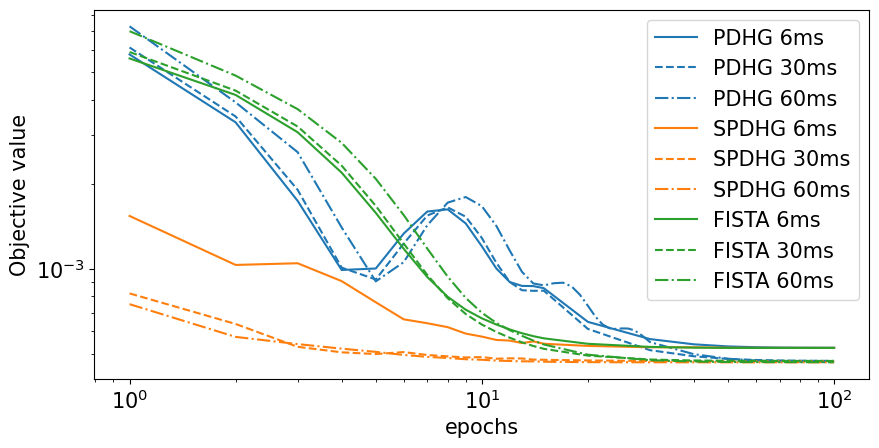

In [106]:
offset = 1
scale = 'log'
linestyle = ['-', '--', '-.']
linecolor = ['C0', 'C1', 'C2']

import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
matplotlib.rcParams.update({'font.size': 15})
# hfont = {'fontname':'Helvetica'}
# plt.rcParams['axes.labelsize'] = 15
# plt.rcParams['axes.titlesize'] = 15
# plt.rcParams['legend.fontsize'] = 15
# plt.rcParams["font.style"] = "normal"
# # plt.rcParams["font.family"] = ""

fig= plt.subplots(nrows=1, ncols=1, squeeze=True, figsize=[10, 4.8])

for i,algo in enumerate([ 'PDHG', 'SPDHG', 'FISTA', ]): #
    for j,num in enumerate(num_ms):
        
        epochs = results[algo][str(num)]['iterations']
        objective = results[algo][str(num)]['objective']
        if algo == 'FISTA' and num==60:
            print(num, epochs, objective)
            filt = [True, True, True, True, True, True, True, True, True, True, 
                    True, True, True, True, True, True, False, False, False, False, 
                    True, False, False, False, False, False, False, False, False, False,
                    True, True, True, True, True, True, True,True,] 
            epochs = epochs [filt]
            objective = objective [filt]
        
        if algo == 'SPDHG':
            epochs = [el / num for el in epochs]
            
        elif algo == 'PDHG':
            filt = results[algo][str(num)]['iterations'] <= resmaxiter
            epochs = results[algo][str(num)]['iterations'][filt]
            objective = results[algo][str(num)]['objective'][filt]
                
        if algo == 'FISTA' and num==60:
            print(num, epochs, objective)
        plt.plot(epochs[offset:], objective[offset:], label=f'{algo} {num}ms' , linestyle=linestyle[j], color=linecolor[i])
        
plt.xscale(scale)
plt.yscale(scale)
plt.xlabel('epochs',)
plt.ylabel('Objective value',)
plt.legend()
plt.show()


60 [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  40  50  60  70  80
  90 100] [0.01693281 0.00700368 0.00486974 0.00370053 0.00280828 0.00209165
 0.00155491 0.00118204 0.00093934 0.00078929 0.00069885 0.00064312
 0.00060597 0.0005785  0.00055668 0.00053904 0.00089008 0.00089396
 0.00086612 0.0008091  0.00049589 0.00067781 0.00063567 0.00061593
 0.00061235 0.00061481 0.00061432 0.00060609 0.00059012 0.00056984
 0.00047412 0.00046892 0.00046723 0.00046671 0.00046652 0.00046645
 0.00046636 0.00046627]


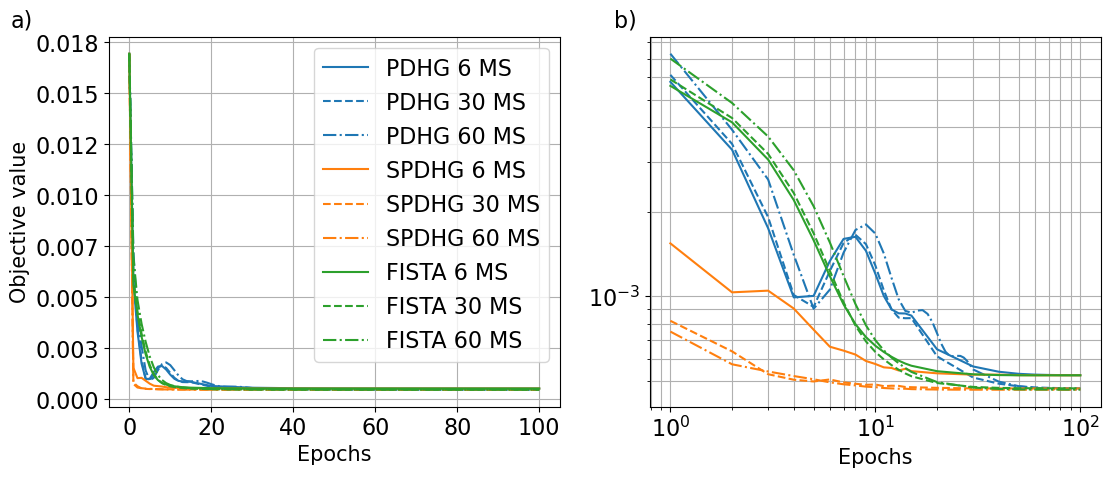

In [175]:
offset = [0,1]
scale = 'log'
linestyle = ['-', '--', '-.']
linecolor = ['C0', 'C1', 'C2']
matplotlib.rcParams.update({'font.size': 16})
# params = {'axes.titlesize':'30', 'axes.labelsize':'15'}
# pylab.rcParams.update(params)
# plt.rcParams['axes.labelsize'] = 15
# plt.rcParams['axes.titlesize'] = 30
# plt.rcParams['figure.titlesize'] = 20
# plt.rcParams['legend.fontsize'] = 15

fig, ax = plt.subplots(nrows=1, ncols=2, squeeze=True, figsize=[6.4 * 2, 4.8])

for i,algo in enumerate(['PDHG', 'SPDHG', 'FISTA']):
    for j,num in enumerate(num_ms):
        epochs = results[algo][str(num)]['iterations']
        objective = results[algo][str(num)]['objective']
        
        if algo == 'FISTA' and num==60:
            print(num, epochs, objective)
            filt = [True, True, True, True, True, True, True, True, True, True, 
                    True, True, True, True, True, True, False, False, False, False, 
                    True, False, False, False, False, False, False, False, False, False,
                    True, True, True, True, True, True, True,True,] 
            epochs = epochs [filt]
            objective = objective [filt]
                    
        if algo == 'SPDHG':
            epochs = [el / num for el in epochs]
        elif algo == 'PDHG':
            # PDHG has 200 epochs, need to filter >100
            filt = results[algo][str(num)]['iterations'] <= resmaxiter
            epochs = results[algo][str(num)]['iterations'][filt]
            objective = results[algo][str(num)]['objective'][filt]

        for k in range(2):
            # ax[k].plot(epochs[offset[k]:], objective[offset[k]:]/objective[0], label=f'{algo} {num} MS' , linestyle=linestyle[j], color=linecolor[i])
            ax[k].plot(epochs[offset[k]:], objective[offset[k]:], label=f'{algo} {num} MS' , linestyle=linestyle[j], color=linecolor[i])

# 

AB=['A', 'B']
for i, dscale in enumerate(['linear', 'log']):    
    ax[i].set_xscale(dscale)
    ax[i].set_yscale(dscale)
    ax[i].set_xlabel('Epochs')
    ax[i].grid(axis='both', which='both')
    # ax[i].set_title(AB[i])
    if i == 0:
        ax[i].set_ylabel('Objective value')
        ax[i].yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
        # ax[i].ticklabel_format('scientific')
        # ax[i].ticklabel_format(axis='y', style='sci')
        ax[i].legend()

plt.figtext(0.048, 0.9, 'a)')
plt.figtext(0.52, 0.9, 'b)')
plt.savefig('objective_for_different_nms.png', bbox_inches = "tight")
plt.show()
